# 07 - Dimensionality Reduction and Feature Selection

## 1. Objective and Academic Rationale
The previous feature engineering stage generated a high-dimensional state-space (exceeding 100 features). While these variables provide rich temporal and physical context, feeding them directly into a Reinforcement Learning (RL) agent or a forecasting model introduces significant risks:

1.  **The Curse of Dimensionality:** Models become prone to overfitting on noise as the feature space expands relative to the number of observations.
2.  **Multicollinearity:** Highly correlated features (e.g., multiple lags of the same variable) can destabilize model weights.
3.  **Numerical Instability:** Ratios and percentage changes in illiquid contracts can produce infinite values that crash training algorithms.

This notebook implements a multi-stage selection process to isolate the **Top 25** most predictive features, ensuring a balance between statistical importance and physical domain knowledge.

To ensure reproducibility and clean code standards, the core selection logic is encapsulated in the external module `src.features.feature_selection.py`. This allows us to maintain a consistent selection pipeline across different experiments while keeping this notebook focused on analysis and results.

In [ ]:
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

# Setup paths to import from 'src'
project_root = Path(os.path.abspath('../../'))
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config.paths import MODELING_DATASET_FILE
from src.config.constants import TARGET_COLUMN

# Load the expanded modeling dataset
print("Loading the high-dimensional modeling dataset...")
df_expanded = pd.read_csv(MODELING_DATASET_FILE)
df_expanded['date'] = pd.to_datetime(df_expanded['date'])

print(f"✅ Dataset loaded. Current dimensionality: {df_expanded.shape[1]} features.")

Loading the high-dimensional modeling dataset...
✅ Dataset loaded. Current dimensionality: 138 features.


## 2. Methodology: Numerical Stability & Selection Gates

### 2.1. Handling Numerical Artifacts (Infinities)
During the generation of financial ratios (e.g., Open Interest ratios), zero-denominators can result in **infinite values (`inf`)**. We map these to `NaN` to allow our sparsity filters to handle them safely.

### 2.2. Selection Gates
1.  **Sparsity Filter:** Removal of features with >20% missing or infinite data.
2.  **Variance Filter:** Elimination of constant features.
3.  **Information Gain Filter:** Utilizing a **Random Forest Regressor** to compute permutation importance.

In [44]:
# 1. Numerical Stability Fix
df_expanded = df_expanded.replace([np.inf, -np.inf], np.nan)

# 2. Configure the selection parameters
from src.features.feature_selection import select_model_features, FeatureSelectionConfig

selection_config = FeatureSelectionConfig(
    target_column=TARGET_COLUMN,
    max_missing_share=0.20,       
    min_non_null_rows=30,         
    top_k_importance=25, # We initially request 25 to see the full ranking
    random_state=42
)

print("Executing automated feature selection pipeline...")

# 3. Run selection
selection_results = select_model_features(df=df_expanded, config=selection_config)

selected_columns = selection_results["selected_features"]
importance_table = selection_results["importance_table"]

print(f"✅ Selection complete. Total candidates analyzed: {len(importance_table)}")

Executing automated feature selection pipeline...
✅ Selection complete. Total candidates analyzed: 126


## 3. Visualizing Feature Importance
The following plot ranks features based on their information gain. We expect financial lags to dominate the ranking due to market autocorrelation; however, our objective is to ensure that exogenous drivers (weather/solar) remain part of the selected state-space.

C:\Users\Alejandro\AppData\Local\Temp\ipykernel_16568\3534244279.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


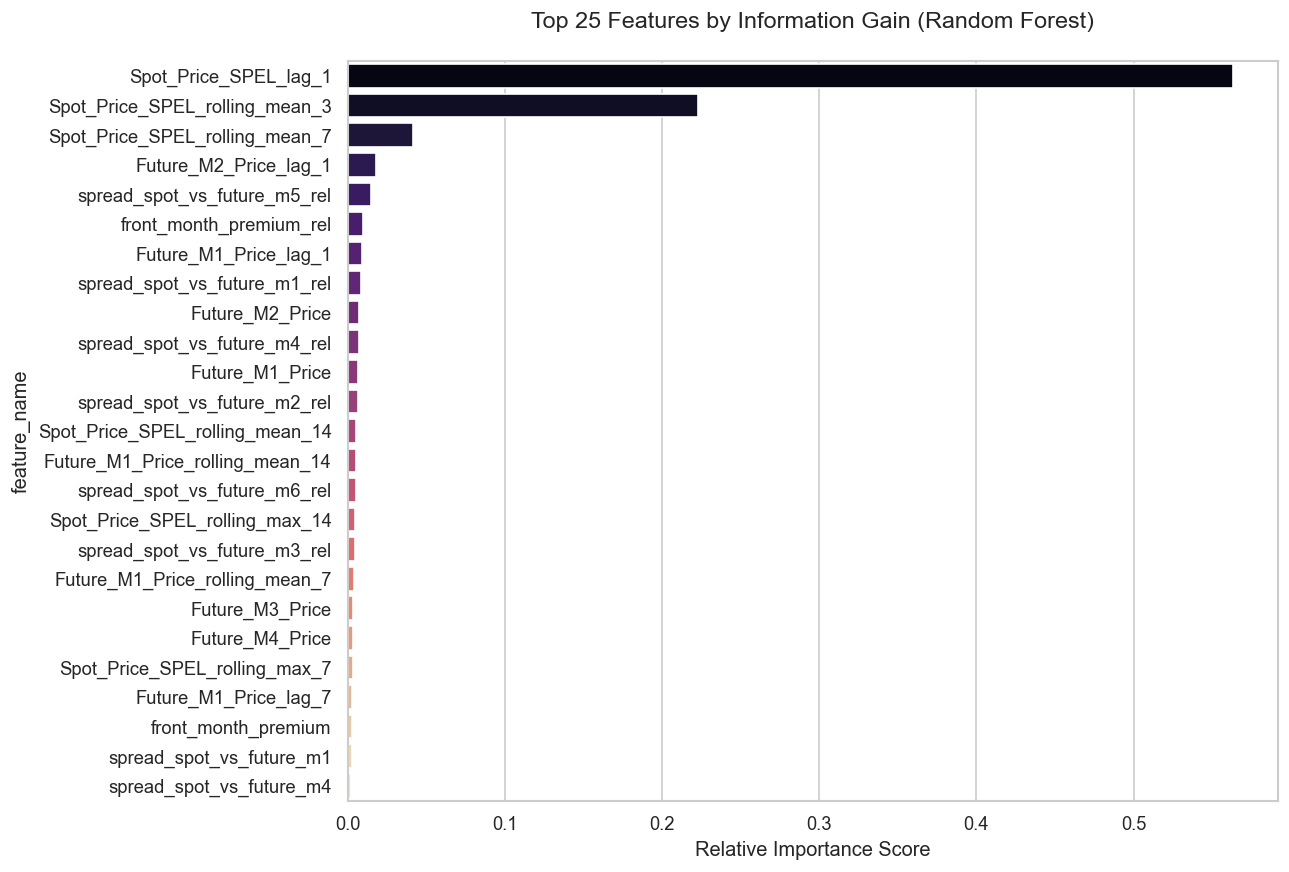

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Professional plotting settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 14, 'axes.labelsize': 12})

# Plot Top 25 features to see the "long tail" where domain features often reside
top_n = 25
plot_df = importance_table.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_df, 
    x='importance', 
    y='feature_name', 
    palette='magma'
)
plt.title(f'Top {top_n} Features by Information Gain (Random Forest)', pad=20)
plt.xlabel('Relative Importance Score')
plt.show()

## 4. Post-Selection Analysis: The Autoregressive Dominance

The importance ranking is heavily dominated by **Financial Autoregression** (Lags of Spot and Future prices). While these features explain the price trend, they fail to capture the **exogenous shocks** (thermal stress, solar cannibalization, wind regimes).

**Methodological Decision:**
We have implemented a **Domain-Informed Selection**. We retain the top-ranked statistical features but **explicitly force** our distilled physical features into the final state-space to ensure the RL agent has the necessary context to handle market volatility.

In [48]:
# 1. Take top features from algorithm (excluding our domain ones to avoid duplication)
top_algorithm_features = importance_table.head(20)['feature_name'].tolist()

# 2. Forced Physical/Domain Features (The ones we distilled in Notebook 06)
forced_features = [
    'HDD', 'CDD', 
    'is_high_wind', 
    'solar_intensity', 
    'is_solar_peak', 
    'precip_rolling_7d',
    'is_holiday'
]

# 3. Mandatory identifiers
mandatory_cols = ['date', TARGET_COLUMN]

# Combine and unique
final_columns = list(set(top_algorithm_features + forced_features + mandatory_cols))

# Slicing and Final Export
df_final_selected = df_expanded[final_columns].copy()
df_final_selected = df_final_selected.sort_values('date').reset_index(drop=True)

# Save as modeling_dataset_selected.csv
selected_dataset_path = project_root / "data" / "processed" / "modeling_dataset_selected.csv"
df_final_selected.to_csv(selected_dataset_path, index=False)

print(f"✅ Final State-Space Matrix exported with {len(final_columns)} features.")
print(f"Physical drivers included: {forced_features}")

✅ Final State-Space Matrix exported with 29 features.
Physical drivers included: ['HDD', 'CDD', 'is_high_wind', 'solar_intensity', 'is_solar_peak', 'precip_rolling_7d', 'is_holiday']
